# Rodar no QisKit os algoritmos: 

# Deutsch-Jozsa

# Bernstein-Vazirani

# Simon 

# Deutsch-Jozsa

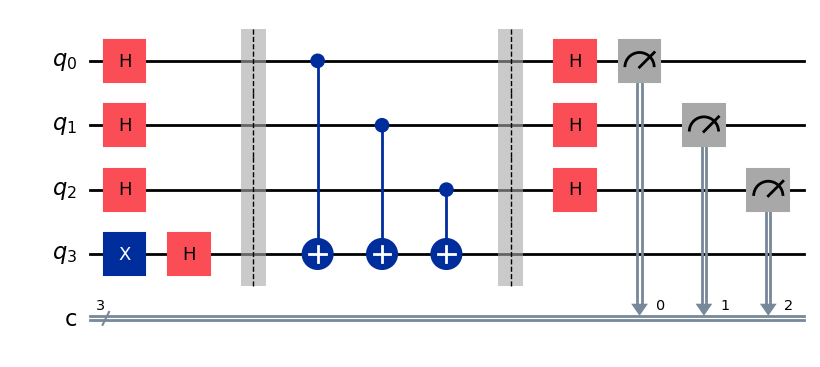

Resultado: {'111': 1024}


In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

n = 3
qc_dj = QuantumCircuit(n + 1, n)

# Prepara o qubit auxiliar em |->
qc_dj.x(n)
qc_dj.h(n)

# Coloca os qubits de entrada em superposição
qc_dj.h(range(n))

qc_dj.barrier()

# Oráculo balanceado
for qubit in range(n):
    qc_dj.cx(qubit, n)

qc_dj.barrier()

# Interferência e medição
qc_dj.h(range(n))
qc_dj.measure(range(n), range(n))

display(qc_dj.draw("mpl"))
plt.show()

simulator = AerSimulator()
result = simulator.run(
    transpile(qc_dj, simulator),
    shots=1024
).result()

print("Resultado:", result.get_counts())

# Bernstein-Vazirani

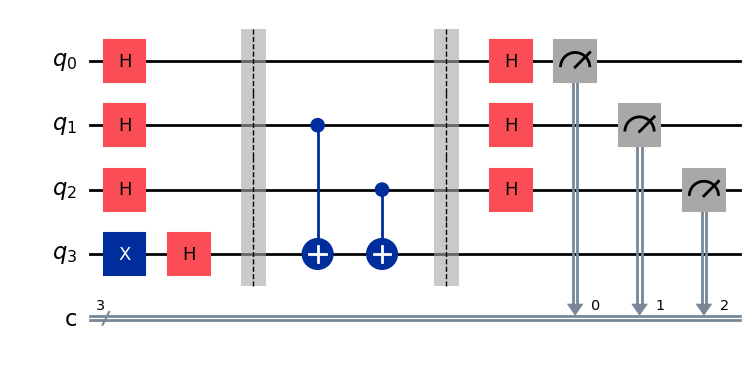

Resultado: {'110': 1024}


In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

secret = "110"
n = len(secret)

qc_bv = QuantumCircuit(n + 1, n)

# Prepara o qubit auxiliar em |->
qc_bv.x(n)
qc_bv.h(n)

# Superposição nas entradas
qc_bv.h(range(n))

qc_bv.barrier()

# Oráculo para o segredo 110
for qubit, bit in enumerate(reversed(secret)):
    if bit == "1":
        qc_bv.cx(qubit, n)

qc_bv.barrier()

# Recuperação do segredo
qc_bv.h(range(n))
qc_bv.measure(range(n), range(n))

display(qc_bv.draw("mpl"))
plt.show()

simulator = AerSimulator()
result = simulator.run(
    transpile(qc_bv, simulator),
    shots=1024
).result()

print("Resultado:", result.get_counts())

# Simon

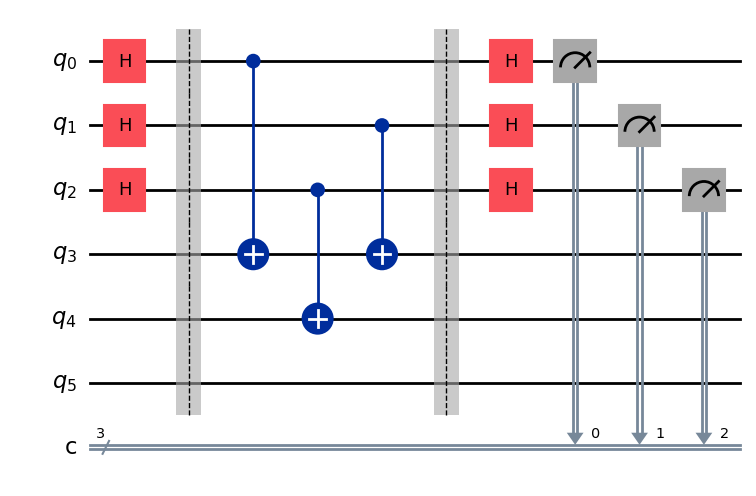

Resultado: {'111': 221, '100': 252, '000': 255, '011': 296}


In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

def simon_oracle():
    oracle = QuantumCircuit(6, name="Qf")

    # f(x0, x1, x2) = (x0 XOR x1, x2, 0)
    oracle.cx(0, 3)
    oracle.cx(1, 3)
    oracle.cx(2, 4)

    return oracle


qc_simon = QuantumCircuit(6, 3)

# Superposição no registrador de entrada
qc_simon.h([0, 1, 2])

qc_simon.barrier()

# Aplicação do oráculo
qc_simon.compose(
    simon_oracle(),
    qubits=range(6),
    inplace=True
)

qc_simon.barrier()

# Interferência e medição
qc_simon.h([0, 1, 2])
qc_simon.measure([0, 1, 2], [0, 1, 2])

display(qc_simon.draw("mpl"))
plt.show()

simulator = AerSimulator()
result = simulator.run(
    transpile(qc_simon, simulator),
    shots=1024
).result()

print("Resultado:", result.get_counts())